# Geodesic Distances with a Stable Heat Method on the Torus

We compute geodesic-like distance maps on a periodic square domain $\Omega=[0,1)^2$
using the heat-method pipeline:
$$
(I - t\Delta)u=\delta_{x_0}, \qquad
X=-\frac{\nabla u}{\|\nabla u\|+\eta}, \qquad
\Delta \phi=\nabla\cdot X.
$$
The final field $\phi$ approximates the distance to the source after shifting $\min \phi=0$.
Using a spectral periodic discretization keeps the computation smooth and avoids high-frequency artifacts.


The periodic Laplacian eigenvalues are
$$
\lambda_{k,\ell}=4\pi^2\left(k^2+\ell^2\right),
$$
which makes both the heat and Poisson solves explicit in Fourier space.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

plt.rcParams["figure.dpi"] = 120


In [2]:
def spectral_operators(n):
    x = np.arange(n) / n
    X, Y = np.meshgrid(x, x, indexing="ij")
    k = np.fft.fftfreq(n, d=1 / n)
    KX, KY = np.meshgrid(k, k, indexing="ij")
    lam = 4 * np.pi**2 * (KX**2 + KY**2)
    return X, Y, KX, KY, lam


def solve_heat_periodic(delta, t, lam):
    u_hat = np.fft.fft2(delta) / (1.0 + t * lam)
    return np.real(np.fft.ifft2(u_hat))


def grad_periodic(u):
    ux = np.roll(u, -1, axis=0) - np.roll(u, 1, axis=0)
    uy = np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)
    return 0.5 * ux, 0.5 * uy


def div_periodic(vx, vy):
    dx = np.roll(vx, -1, axis=0) - np.roll(vx, 1, axis=0)
    dy = np.roll(vy, -1, axis=1) - np.roll(vy, 1, axis=1)
    return 0.5 * dx + 0.5 * dy


def solve_poisson_periodic(rhs, lam):
    rhs_hat = np.fft.fft2(rhs)
    phi_hat = np.zeros_like(rhs_hat)
    mask = lam > 0
    phi_hat[mask] = rhs_hat[mask] / lam[mask]
    phi = np.real(np.fft.ifft2(phi_hat))
    return phi - phi.min()


def heat_distance(n, src_i, src_j, t=2e-4):
    _, _, _, _, lam = spectral_operators(n)
    delta = np.zeros((n, n))
    delta[src_i % n, src_j % n] = 1.0
    u = solve_heat_periodic(delta, t, lam)
    ux, uy = grad_periodic(u)
    norm = np.sqrt(ux**2 + uy**2) + 1e-10
    vx, vy = -ux / norm, -uy / norm
    rhs = div_periodic(vx, vy)
    phi = solve_poisson_periodic(rhs, lam)
    return u, phi


We first compare several values of the heat time $t$.
Larger $t$ oversmooths near the source; smaller $t$ captures sharper local behavior but can become noisy if too small.


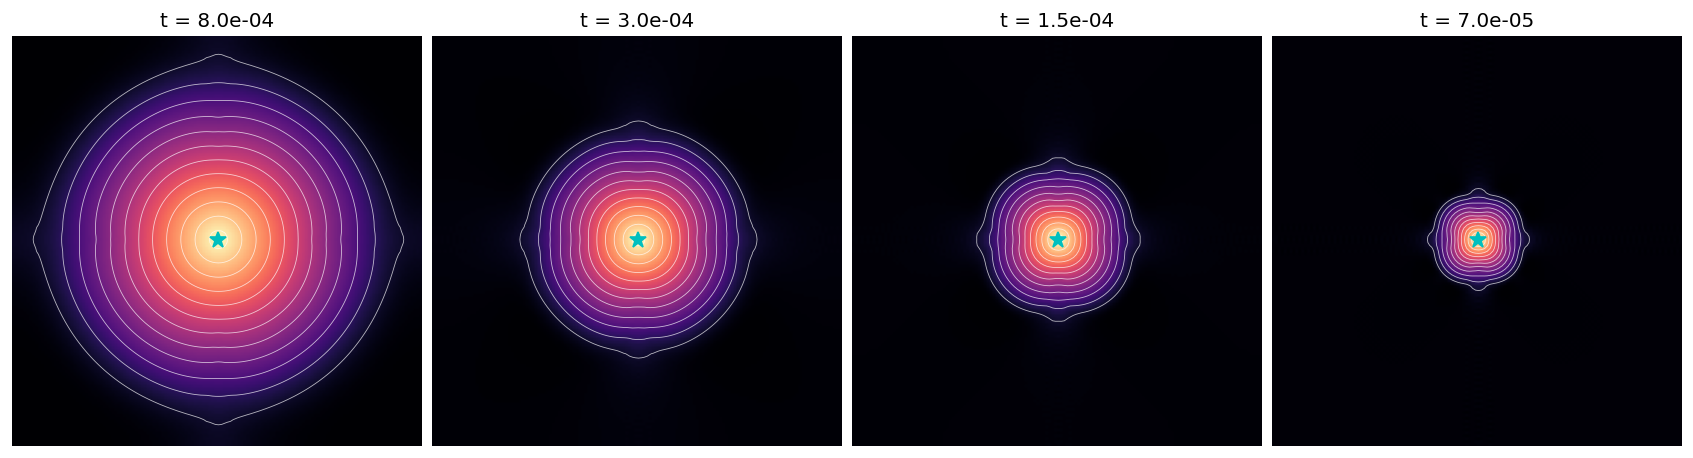

In [3]:
n = 140
src = (n // 2, n // 2)
t_vals = [8e-4, 3e-4, 1.5e-4, 7e-5]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), constrained_layout=True)
for ax, t in zip(axes, t_vals):
    _, d = heat_distance(n, src[0], src[1], t=t)
    dn = d / (d.max() + 1e-14)
    ax.imshow(dn.T, origin="lower", cmap="magma", vmin=0, vmax=1)
    ax.contour(dn.T, levels=12, colors="white", linewidths=0.5, alpha=0.7)
    ax.plot(src[0], src[1], "c*", ms=10)
    ax.set_title(f"t = {t:.1e}")
    ax.axis("off")
plt.show()


To evaluate quality, we compare the periodic Euclidean distance
$$
d_{\mathbb{T}^2}(x,x_0)=\sqrt{\min(|\Delta x|,1-|\Delta x|)^2 + \min(|\Delta y|,1-|\Delta y|)^2}
$$
against the heat-method approximation.


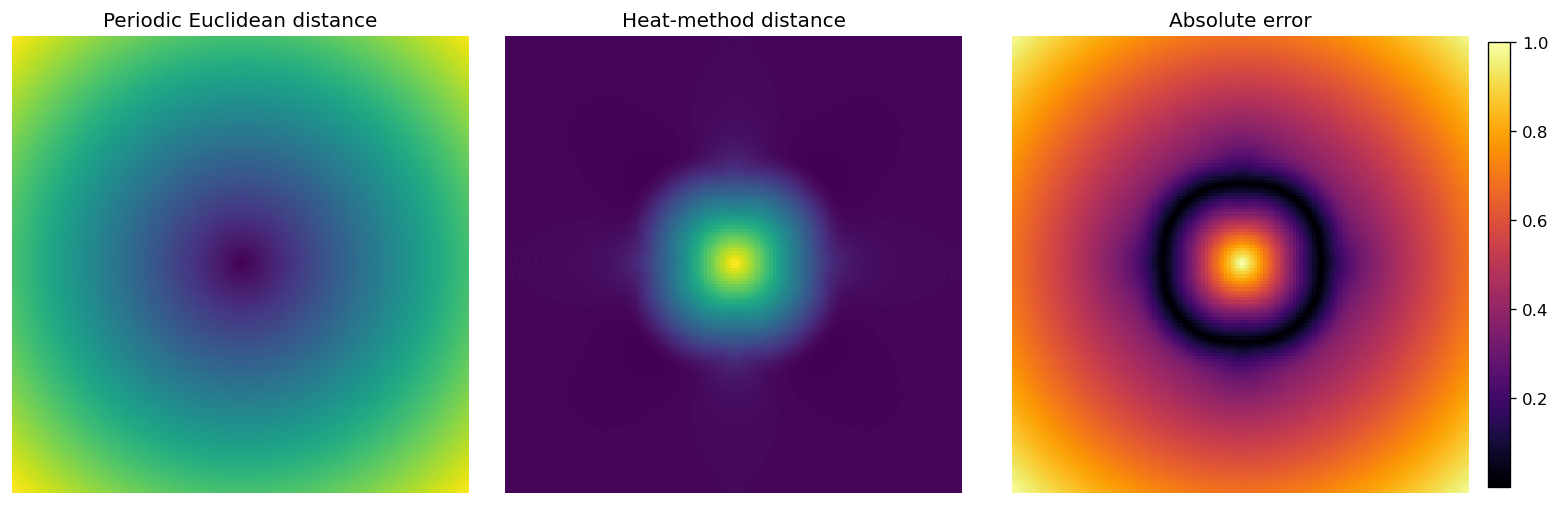

In [4]:
X, Y, *_ = spectral_operators(n)
x0, y0 = src[0] / n, src[1] / n
dx = np.minimum(np.abs(X - x0), 1 - np.abs(X - x0))
dy = np.minimum(np.abs(Y - y0), 1 - np.abs(Y - y0))
d_true = np.sqrt(dx**2 + dy**2)
_, d_heat = heat_distance(n, src[0], src[1], t=2e-4)

dtn = d_true / d_true.max()
dhn = d_heat / d_heat.max()
err = np.abs(dhn - dtn)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.1), constrained_layout=True)
axes[0].imshow(dtn.T, origin="lower", cmap="viridis")
axes[0].set_title("Periodic Euclidean distance"); axes[0].axis("off")
axes[1].imshow(dhn.T, origin="lower", cmap="viridis")
axes[1].set_title("Heat-method distance"); axes[1].axis("off")
im = axes[2].imshow(err.T, origin="lower", cmap="inferno")
axes[2].set_title("Absolute error"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()


With multiple sources, we compute one distance field per source and assign each point to the closest one,
which yields a geodesic Voronoi tessellation on the periodic domain.


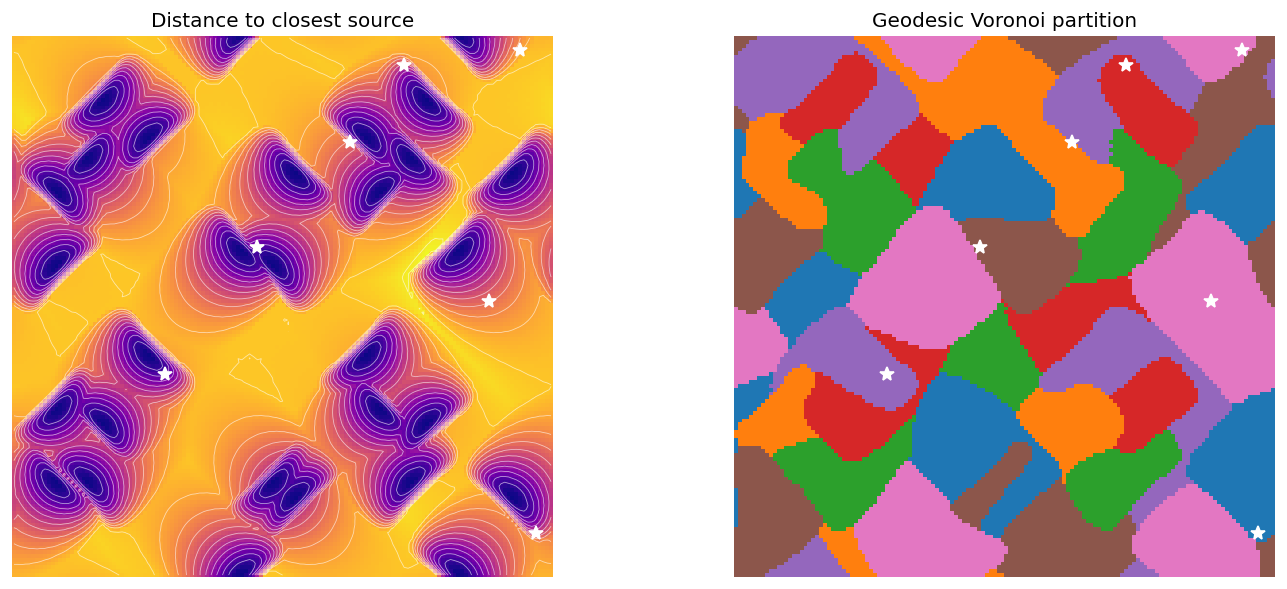

In [5]:
rng = np.random.default_rng(4)
srcs = rng.integers(0, n, size=(7, 2))

D_stack = []
for i, j in srcs:
    _, d = heat_distance(n, int(i), int(j), t=2e-4)
    D_stack.append(d)
D_stack = np.stack(D_stack, axis=2)
labels = np.argmin(D_stack, axis=2)
dmin = np.min(D_stack, axis=2)
dmin = dmin / (dmin.max() + 1e-14)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].imshow(dmin.T, origin="lower", cmap="plasma")
axes[0].contour(dmin.T, levels=12, colors="white", linewidths=0.5, alpha=0.6)
for i, j in srcs:
    axes[0].plot(i, j, "w*", ms=9)
axes[0].set_title("Distance to closest source"); axes[0].axis("off")

axes[1].imshow(labels.T, origin="lower", cmap="tab10", vmin=0, vmax=9)
for i, j in srcs:
    axes[1].plot(i, j, "w*", ms=9)
axes[1].set_title("Geodesic Voronoi partition"); axes[1].axis("off")
plt.show()


Interactive exploration of the source position and heat time.


## Bibliographical Resources

- K. Crane, C. Weischedel, M. Wardetzky, “Geodesics in Heat,” *ACM Transactions on Graphics*, 2013.
- G. Peyré and M. Cuturi, *Computational Optimal Transport*, Foundations and Trends in Machine Learning, 2019.
- J. A. Sethian, *Level Set Methods and Fast Marching Methods*, Cambridge University Press, 1999.
